## Assignment 2 (70 marks)
#### =====================================================================================================
### Deadline: 03/09 11:59 pm
#### =====================================================================================================

### Problem 1: Classification (35 marks)

`lab02_dataset_1.xlsx` contains 10,302 observations on various vehicles. You will use the observations in this dataset to train models that predict the usage of a vehicle. The input features which will be used for your training are *AGE, TRAVTIME, CAR_TYPE, OCCUPATION, EDUCATION* and your output label is the binary class *CAR_USE*, whose values are *Private* and *Commercial*.

### 1.a (2 marks)
For the 5 input features, drop any rows with missing values. Output the new length of the training dataset after you drop the missing values among the input features.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

df = pd.read_excel('lab02_dataset_1.xlsx')

input_features = ["AGE", "TRAVTIME", "CAR_TYPE", "OCCUPATION", "EDUCATION"]
output_label = "CAR_USE"
New_features = df.dropna(subset=input_features) # drop any rows with missing values
New_features




,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,...,TIF,CAR_TYPE,RED_CAR,REVOKED,MVR_PTS,CAR_AGE,URBANICITY,CLM_AMT,CLM_COUNT,EXPOSURE
0,63581743,0,1939-03-16,60.0,0,11.0,67000.0,No,NaN,No,...,11,Minivan,yes,No,3,18.0,Highly Urban/ Urban,0,0,0.189
1,132761049,0,1956-01-21,43.0,0,11.0,91000.0,No,257000.0,No,...,1,Minivan,yes,No,0,1.0,Highly Urban/ Urban,0,0,1.000
2,921317019,0,1951-11-18,48.0,0,11.0,53000.0,No,NaN,No,...,1,Van,yes,No,2,10.0,Highly Urban/ Urban,0,0,1.000
3,727598473,0,1964-03-05,35.0,1,10.0,16000.0,No,124000.0,Yes,...,4,SUV,no,No,3,10.0,Highly Urban/ Urban,0,0,0.828
4,450221861,0,1948-06-05,51.0,0,14.0,NaN,No,306000.0,Yes,...,7,Minivan,yes,No,0,6.0,Highly Urban/ Urban,0,0,0.729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10297,67790126,1,1954-08-13,45.0,2,9.0,165000.0,No,386000.0,Yes,...,15,Minivan,no,No,2,17.0,Highly Urban/ Urban,0,0,1.000
10298,61970712,0,1953-06-17,46.0,0,9.0,107000.0,No,333000.0,Yes,...,6,Panel Truck,no,No,0,1.0,Highly Urban/ Urban,0,0,1.000
10299,849208064,0,1951-06-18,48.0,0,15.0,40000.0,No,171000.0,Yes,...,7,SUV,no,No,0,1.0,Highly Urban/ Urban,0,0,1.000
10300,627828331,0,1948-12-12,50.0,0,7.0,43000.0,No,149000.0,Yes,...,6,Minivan,no,No,0,11.0,Highly Urban/ Urban,0,0,1.000


### 1.b (6 marks)
We want to encode categorical features as an integer array. Look up which sklearn function will allow you to do that and apply that on the input features. Also, remember to standardize your encoded features using `fit_transform` to create your final dataset. Finally, perform a 80-20 split on your dataset (80% for training, 20% for testing).

In [7]:
# encode categorical features

# identify categorical and noncategorical
categorical_features = ["CAR_TYPE", "OCCUPATION", "EDUCATION"] #str
noncategorical_features = ["AGE", "TRAVTIME"] # int or float

encoder = OneHotEncoder(sparse_output=False)

# standarlize encoded features for categorical
encoded_features = encoder.fit_transform(New_features[categorical_features])
encoded_names = encoder.get_feature_names_out(categorical_features)
df_categorical = pd.DataFrame(encoded_features, columns=encoded_names, index=New_features.index)

# noncategorical
noncategorical_newfeatures = New_features[noncategorical_features]

df_result = pd.concat([df_categorical, noncategorical_newfeatures], axis=1)

# split training and testing
X_train, X_test, y_train, y_test = train_test_split(df_result, New_features["CAR_USE"], test_size=0.2, random_state=42) # 42 is widely used

df_result.head()


,CAR_TYPE_Minivan,CAR_TYPE_Panel Truck,CAR_TYPE_Pickup,CAR_TYPE_SUV,CAR_TYPE_Sports Car,CAR_TYPE_Van,OCCUPATION_Blue Collar,OCCUPATION_Clerical,OCCUPATION_Doctor,OCCUPATION_Home Maker,...,OCCUPATION_Professional,OCCUPATION_Student,OCCUPATION_Unknown,EDUCATION_Bachelors,EDUCATION_Below High Sc,EDUCATION_High School,EDUCATION_Masters,EDUCATION_PhD,AGE,TRAVTIME
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,60.0,14
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,43.0,22
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48.0,26
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,35.0,5
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,51.0,32


### 1.c (6 marks)

i. Train a logistic regression model using sklearn's [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).
<br>
ii. Train a naive bayes model using sklearn's [`CategoricalNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.CategoricalNB.html) with a laplace smoothing of 0.5.

In [8]:
# logistic
logis_reg = LogisticRegression(max_iter=400)
logis_reg.fit(X_train, y_train)
lr_predict = logis_reg.predict(X_test)

# naive bayes 
naive_bayes = CategoricalNB(alpha = 0.5)
naive_bayes.fit(X_train, y_train)
nb_predict = naive_bayes.predict(X_test)

/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 1.d (6 marks)
Compute and output the `accuracy_score` for both the classification models you learned on the testing partition.

In [10]:
lg_accuracy = accuracy_score(y_test, lr_predict)
nb_accuracy = accuracy_score(y_test, nb_predict)
print(f"LR: {lg_accuracy}")
print(f"NB: {nb_accuracy}")

LR: 0.8853812530354541
NB: 0.8678970373967946


### 1.e (6 marks)

Let us study a few fictitious persons (test cases). Use the `CategoricalNB` model for this task.
<br>
Person 1, whose age is 45, has a travel time of 46, works in a Manager occupation, has an education level of Masters, and owns a Minivan.
<br>
Person 2, whose age is 51, has a travel time of 32, works in a Clerical occupation, has an education level of Below High Sc, and owns a Pickup.
<br>
Person 3, whose age is 25, has a travel time of 14, works in a Blue Collar occupation, has an education level of High School, and owns a SUV.

Display a datraframe that captures all the above information, alongwith two additional columns which will display the `Car Use` probabilities of these three people.

In [13]:
persons = pd.DataFrame({
    "AGE": [45, 51, 25],
    "TRAVTIME": [46, 32, 14],
    "CAR_TYPE": ["Minivan", "Pickup", "SUV"],
    "OCCUPATION": ["Manager", "Clerical", "Blue Collar"],
    "EDUCATION": ["Masters", "Below High Sc", "High School"]
})
# categorical for features with str
new_categorical_features = encoder.transform(persons[["CAR_TYPE", "OCCUPATION", "EDUCATION"]])
# noncategorical for features with number
new_noncategorical_features = persons[["AGE", "TRAVTIME"]].values

df_new = pd.concat([pd.DataFrame(new_categorical_features), 
                          pd.DataFrame(new_noncategorical_features)], axis=1)
nb_prob = naive_bayes.predict_proba(df_new)
persons["CAR_USE_0"] = nb_prob[:, 0]
persons["CAR_USE_1"] = nb_prob[:, 1]

persons

/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


,AGE,TRAVTIME,CAR_TYPE,OCCUPATION,EDUCATION,CAR_USE_0,CAR_USE_1
0,45,46,Minivan,Manager,Masters,0.045459,0.954541
1,51,32,Pickup,Clerical,Below High Sc,0.197630,0.802370
2,25,14,SUV,Blue Collar,High School,0.718599,0.281401


### 1.f (5 marks)
Generate a histogram of the predicted probabilities of `CAR_USE = Private` using the `CategoricalNB` model.  The bin width is 0.05.  The vertical axis is the proportion of **all the observations** (all observations imply both the training + testing dataset as it was in 1.b).

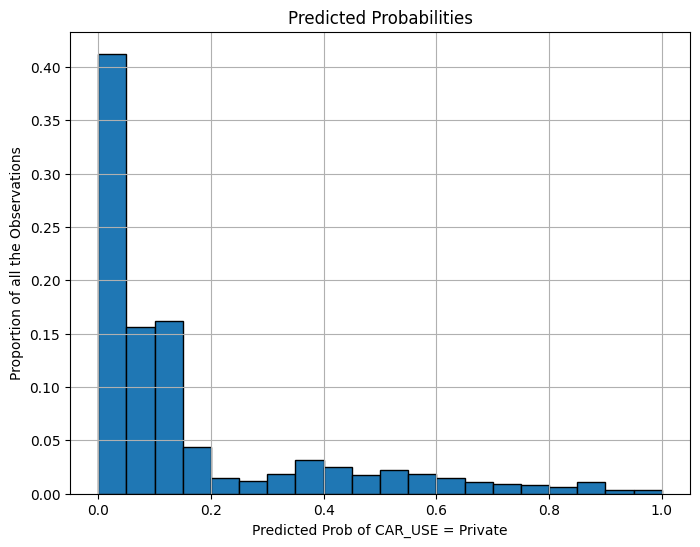

In [16]:
prediction_pred = naive_bayes.predict(df_result)
prediction_prob = naive_bayes.predict_proba(df_result)
prediction = pd.concat([
    pd.DataFrame(prediction_prob, index=New_features.index, columns=['Prob_Private', 'Prob_Commercial']),
    New_features["CAR_USE"]
], axis=1)

prediction = prediction[['Prob_Private', 'CAR_USE']]
private_prob = prediction[prediction['CAR_USE'] == 'Private']

plt.figure(figsize=(8, 6))
plt.hist(private_prob['Prob_Private'], bins=np.arange(0, 1.05, 0.05), weights=np.ones(len(private_prob['Prob_Private'])) / len(private_prob['Prob_Private']), edgecolor='black')

plt.xlabel('Predicted Prob of CAR_USE = Private')
plt.ylabel('Proportion of all the Observations')
plt.title('Predicted Probabilities')
plt.grid(True)

plt.show()

### 1.g (4 marks)
Using a classification threshold of 0.6 i.e., the class with a probability >= 0.6 is the correct output, what is the misclassification rate (computed on **all the observations**) of the `CategoricalNB` model?

In [18]:
threshold = 0.6

prediction_prob2 = naive_bayes.predict_proba(X_test)

predicted_result = np.where(prediction_prob2[:, 1] >= threshold, 'Commercial', 'Private')

misclass_rate = np.mean(predicted_result != y_test)

print(f"{misclass_rate:.4f}")

0.8708


### Problem 2: Linear Regression (20 marks)

`lab02_dataset_2.csv` contains 238 observations on customer purchase history. You will use the observations in this dataset to train models that predict the loyalty score of a customer. The input features which will be used for your training are *age, annual_income, purchase_amount, purchase_frequency* and your output label is *loyalty_score*.

### 2.a (2 marks)

Use sklearn's [`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) and `fit_transform` to transform the input features. Then apply a train-test split of 80-20 to generate the training and testing sets.

In [21]:
df2 = pd.read_csv('lab02_dataset_2.csv')
input_features2 = df2[['age', 'annual_income', 'purchase_amount', 'purchase_frequency']]
output_class2 = df2['loyalty_score']
scaler2 = MinMaxScaler()
X_scaled2 = scaler2.fit_transform(input_features2)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_scaled2, output_class2, test_size=0.2, random_state=42)

print(f"X_train: {X_train2.shape}")
print(f"X_test: {X_test2.shape}")
print(f"y_train: {y_train2.shape}")
print(f"y_test: {y_test2.shape}")


X_train: (190, 4)
X_test: (48, 4)
y_train: (190,)
y_test: (48,)


### 2.b (10 marks)
Complete the empty functions inside the `myLinearRegression` class so that you can be perform linear regression **without using sklearn**. You are free to add additional helper functions if you need them. We will use a learning rate of 0.01 and 1000 training iterations for the learning task.

In [28]:
class myLinearRegression():
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    # Model fitting. Initialize all the weights and bias with 0.0. Update them using gradient descent.
    # Use the linear regression formulation as shown in the slides: W = W - (learning_rate/n)*sum[X(W.X - Y)]
    def fit(self, X, Y):
        # initialization
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # training iteration
        for _ in range(self.iterations):
            y_predicted = np.dot(X, self.weights) + self.bias
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - Y))
            db = (1 / n_samples) * np.sum(y_predicted - Y)            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

model2 = myLinearRegression(learning_rate = 0.01, iterations = 1000)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2) 
print(y_pred2[:10])

[9.70936527 3.08492182 9.13212733 9.04068335 6.3570288  8.81641303
 5.45310341 8.05290846 7.92421116 6.74595384]


### 2.c (2 marks)
Compute and output the `mean_squared_error` between the prediction and the true test labels.

In [30]:
mse = mean_squared_error(y_test2, y_pred2)
mse

0.046968331102934635

### 2.d (6 marks)
Now using sklearn's [`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) and [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) learn two corresponding models using the same training set and test it on the test set. Output the `mean_squared_error` of both the models.

In [31]:
# SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01, random_state=42)
linear_reg = LinearRegression()
sgd_reg.fit(X_train2, y_train2)
linear_reg.fit(X_train2, y_train2)

y_pred_sgd = sgd_reg.predict(X_test2)
y_pred_linear = linear_reg.predict(X_test2)

sgd_mse = mean_squared_error(y_test2, y_pred_sgd)
linear_mse = mean_squared_error(y_test2, y_pred_linear)

sgd_mse, linear_mse

(0.048408035238759105, 0.03712571415557892)

### Problem 3: Regularization (15 marks)

`lab02_dataset_3.csv` has 6,435 observations pertaining to Walmart sales and employment. The input features for your training task are *Weekly_Sales, Holiday_Flag, Temperature, Fuel_Price, CPI* and the output label is *Unemployment*. For this problem, you will be using regression with regularization. 

### 3.a (3 marks)

Use sklearn's [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) and `fit_transform` to transform the input features.

In [33]:
df3 = pd.read_csv('lab02_dataset_3.csv')
input_features3 = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI']
X3 = df3[input_features3]
y3 = df3['Unemployment']

scaler3 = StandardScaler()
X_scaled3 = scaler3.fit_transform(X3)
X_scaled_df3 = pd.DataFrame(X_scaled3, columns=input_features3)
X_scaled_df3.head()

,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI
0,1.057420,-0.274204,-0.995136,-1.713800,1.004175
1,1.054348,3.646917,-1.201170,-1.766089,1.007880
2,1.001206,-0.274204,-1.124178,-1.840166,1.009074
3,0.642828,-0.274204,-0.760907,-1.737766,1.009849
4,0.899914,-0.274204,-0.767955,-1.598328,1.010624


### 3.b (4 marks)

Use sklearn's [`ridge_regression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html) with `alpha=1.5` to compute the coefficients of the linear regression model. What are the two most important features (feature with the largest positive/negative weights are the most relevant)?

In [37]:
ridge_reg = Ridge(alpha=1.5)
ridge_reg.fit(X_scaled3, y3)

coeff_df = pd.DataFrame({
    'Feature': input_features3,
    'Coefficient': ridge_reg.coef_
})
coeff_sorted = coeff_df.reindex(coeff_df['Coefficient'].abs().sort_values(ascending=False).index)
print(coeff_sorted.head(2))

       Feature  Coefficient
4          CPI    -0.680484
2  Temperature     0.337542


Two most important features:

### 3.c (4 marks)
Compute the Pearson correlation coefficient between the input features and the output.

In [38]:
df_correlation = df3[input_features3 + ['Unemployment']].corr()
pearson_correlation = df_correlation['Unemployment'].drop('Unemployment')
print(pearson_correlation)

Weekly_Sales   -0.106176
Holiday_Flag    0.010960
Temperature     0.101158
Fuel_Price     -0.034684
CPI            -0.302020
Name: Unemployment, dtype: float64


The correlation coefficient aligns well with the feature importance as seen in 3.b. Yes or No? 

### 3.d (4 marks)
Create a correlation heatmap using the input features and the output.

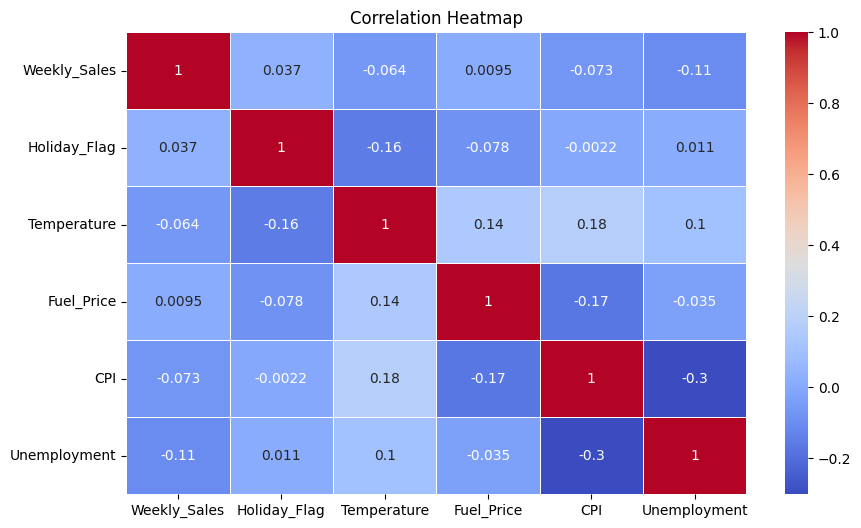

In [39]:
correlation_matrix = df3[input_features3 + ['Unemployment']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()